In [ ]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from src.features.extract_features import get_mel_spectrogram, get_mfcc

In [5]:
DCASE2024_ROOT_PATH = Path("data/raw/dcase-2024")

DCASE2024_TRAIN_PATH = DCASE2024_ROOT_PATH / "Train"
DCASE2024_DEV_PATH = DCASE2024_ROOT_PATH / "Dev"
DCASE2024_EVAL_PATH = DCASE2024_ROOT_PATH / "Eval"

In [4]:
DCASE2024_ROOT_PATH

WindowsPath('c:/Users/josel/OneDrive/Desktop/data/raw/dcase-2024')

In [7]:
DCASE2022_ROOT_PATH = Path("data/raw/dcase-2022")

DCASE2022_TRAIN_PATH = DCASE2022_ROOT_PATH / "Train"
DCASE2022_DEV_PATH = DCASE2022_ROOT_PATH / "Dev"

In [ ]:
# LABELS_ROOT_PATH = 'data/ground_truth_data'

# for machine_dir in Path(DCASE2024_EVAL_PATH).iterdir():
#     data_dir = machine_dir / 'test'
#     labels_path = LABELS_ROOT_PATH + f'/ground_truth_{machine_dir.name}_section_00_test.csv'
#     labels_df = pd.read_csv(labels_path, names=['filename', 'label'], header=None)
#     labels_df.set_index('filename', inplace=True)

#     for sound_file in data_dir.iterdir():
#         #name = sound_file.name.removeprefix('normal_').removeprefix('anomaly_')
#         #sound_file.rename(sound_file.with_name(name))
#         if sound_file.name in labels_df.index:
#             label = labels_df.loc[sound_file.name, 'label']
#             label_name = 'normal' if label == 0 else 'anomaly'
#             new_name = f'{sound_file.name.removesuffix('.wav')}_source_eval_{label_name}.wav'

#             sound_file.rename(sound_file.with_name(new_name))


In [ ]:
SAMPLE_RATE = 24_000

MEL_SPECTROGRAM_PARAMS = {
    "n_fft": 128,
    "sr": SAMPLE_RATE,
    "hop_length": 512,
    "window": "hann",
    "center": True,
    "pad_mode": "constant",
    "power": 2.0,
}

MFCC_PARAMS = {
    "sr": SAMPLE_RATE,
    "n_mfcc": 13,
    "dct_type": 2,
    "norm": "ortho",
    "lifter": 0,
}

In [ ]:
def load_audio(audio):
    signal, sample_rate = librosa.load(audio, sr=SAMPLE_RATE)

    return signal, sample_rate


def get_mel_spectrogram(signal, params):
    mel_spectrogram = librosa.feature.melspectrogram(y=signal, **params)

    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

    return log_mel_spectrogram


def get_mfcc(log_mel_spectrogram, params):
    mfccs = librosa.feature.mfcc(S=log_mel_spectrogram, **params)

    return mfccs


def get_features(signals):
    X_mel_spectrogram = []
    X_mfcc = []

    for signal in signals:
        mel = get_mel_spectrogram(signal, MEL_SPECTROGRAM_PARAMS)
        mfcc = get_mfcc(mel, MFCC_PARAMS)

        X_mel_spectrogram.append(mel)
        X_mfcc.append(mfcc)

    return X_mel_spectrogram, X_mfcc

# Leitura dos áudios


In [ ]:
def read_dcase_dev_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        for section in ["train", "test"]:
            data_dir = machine_dir / section
            if not data_dir.exists():
                continue

            for audio_file in tqdm(data_dir.iterdir(), desc=f"Lendo {section}"):
                if audio_file.suffix != ".wav":
                    continue

                try:
                    if "anomaly" in audio_file.name:
                        label = 1
                    else:
                        label = 0

                    signal, _ = load_audio(audio_file)

                    X.append(signal)
                    machine_type.append(machine_dir.name)
                    y.append(label)

                except Exception as e:
                    print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y


def read_dcase_train_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "train"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo train"):
            if audio_file.suffix != ".wav":
                continue
            try:
                label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y


def read_dcase_eval_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "test"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo eval"):
            if audio_file.suffix != ".wav":
                continue
            try:
                if "anomaly" in audio_file.name:
                    label = 1
                else:
                    label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y

In [ ]:
# Conjuntos que o artigo usa

# 25.199 áudios (treino e teste) - DCASE 2022/MIMII DG
X_dcase22, mtypes_dcase22, y_dcase22 = read_dcase_dev_set(DCASE2022_DEV_PATH)

# # 9.000 áudios (treino) - DCASE 2024
# X_dcase24_train, mtypes_dcase24_train, y_dcase24_train = read_dcase_train_set(DCASE2024_TRAIN_PATH)

# # 1.800 áudios (teste) - DCASE 2024
# X_dcase24_test, mtypes_dcase24_test, y_dcase24_test = read_dcase_eval_set(DCASE2024_EVAL_PATH)

# # União do conjunto DCASE 2024
# X_dcase24 = X_dcase24_test + X_dcase24_train
# mtypes_dcase24 = mtypes_dcase24_test + mtypes_dcase24_train
# y_dcase24 = y_dcase24_test + y_dcase24_train

In [ ]:
X, machine_type, y = read_dcase_eval_set(DCASE2024_EVAL_PATH)

print("Leitura Concluída!")
print(f"Total de amostras: {len(y)}")
print(f"Máquinas: {np.unique(machine_type)}")
print(f"Classes encontradas em y: {np.unique(y)}")

Lendo eval: 200it [00:04, 49.70it/s]
Lendo eval: 200it [00:05, 38.41it/s]
Lendo eval: 200it [00:06, 32.23it/s]
Lendo eval: 200it [00:06, 32.45it/s]
Lendo eval: 200it [00:06, 30.93it/s]
Lendo eval: 200it [00:06, 29.39it/s]
Lendo eval: 200it [00:07, 27.77it/s]
Lendo eval: 200it [00:08, 23.12it/s]
Lendo eval: 200it [00:07, 28.34it/s]

Leitura Concluída!
Total de amostras: 1800
Máquinas: ['3DPrinter' 'AirCompressor' 'BrushlessMotor' 'HairDryer' 'HoveringDrone'
 'RoboticArm' 'Scanner' 'ToothBrush' 'ToyCircuit']
Classes encontradas em y: [0 1]


In [ ]:
X_mel_spectrogram, X_mfcc = get_features(X)

c:\Users\josel\OneDrive\Desktop\NCIA\.venv\Lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


In [ ]:
if len(X_mel_spectrogram) > 0:
    print(f"Formato de um Mel-Spectrograma: {X_mel_spectrogram[0].shape}")

Formato de um Mel-Spectrograma: (128, 469)


1


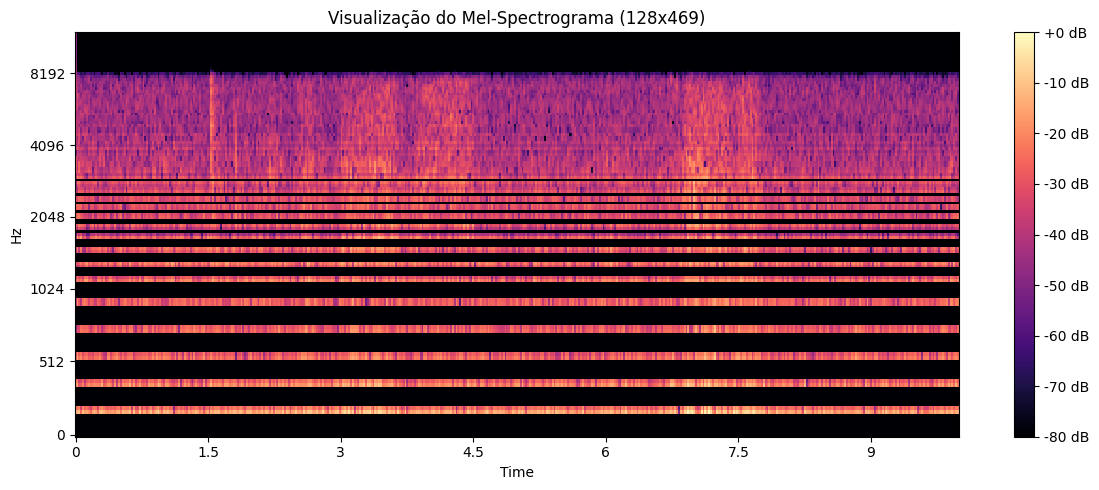

In [ ]:
i = 4

imagem = X_mel_spectrogram[i]
print(y[i])

plt.figure(figsize=(12, 5))
librosa.display.specshow(imagem, sr=24000, hop_length=512, x_axis="time", y_axis="mel")

plt.colorbar(format="%+2.0f dB")
plt.title("Visualização do Mel-Spectrograma (128x469)")
plt.tight_layout()
plt.show()

In [62]:
classes, contagem = np.unique(y, return_counts=True)

print(f"Normais (0): {contagem[0]}")
print(f"Anomalias (1): {contagem[1]}")

Normais (0): 900
Anomalias (1): 900


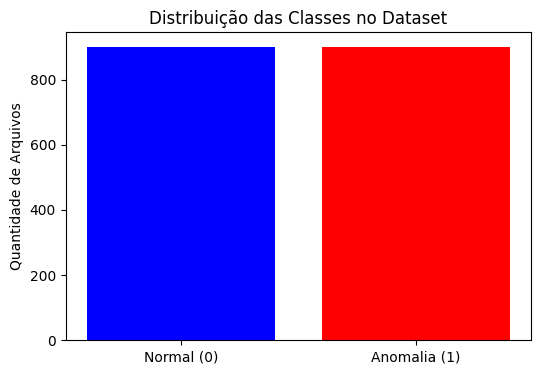

In [63]:
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar(["Normal (0)", "Anomalia (1)"], counts, color=["blue", "red"])
plt.title("Distribuição das Classes no Dataset")
plt.ylabel("Quantidade de Arquivos")
plt.show()